# MVP v0.2: Stitch-OPE on Robomimic — With Policy Guidance

**Date:** 2026-03-10  
**Builds on:** MVP v0.1 (unguided pipeline smoke test)

**Goal:** Add policy guidance to steer synthetic trajectory generation toward the target policy.
Without guidance (v0.1), OPE estimated the behavior policy value (14.96) instead of the target policy value (0.54).

**Approach (simplest):**
1. Load v0.1's trained diffusion model (no retraining)
2. Build target policy (robomimic diffusion policy) and query it on demo states to get target actions
3. Train a BC_Gaussian proxy on (state, target_action) pairs — gives us analytic `log_prob` for guidance
4. Run SOPE-style guided stitching: at each denoising step, nudge actions toward target policy via ∇_a log π(a|s)
5. Compare guided OPE estimate to oracle and to unguided baseline

**Key change:** `generate_guided_trajectories()` adds a guidance gradient at each denoising step,
following SOPE's `default_sample_fn()` pattern from `diffusion.py:152-250`.

In [1]:
import sys, os
import numpy as np
import torch
import torch.nn as nn
import h5py
import json
import matplotlib.pyplot as plt
from pathlib import Path
from collections import OrderedDict
from copy import deepcopy
from tqdm import tqdm

# Project root
PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

# SOPE imports
from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import EMA, apply_conditioning

# Robomimic imports
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils
from robomimic.algo import RolloutPolicy

# Our imports
from latent_sope.robomimic_interface.checkpoints import (
    load_checkpoint, build_rollout_policy_from_checkpoint, build_env_from_checkpoint
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
CKPT_DIR = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models/test/20260309132349"
DIFFUSION_CKPT_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_sope"
RESULTS_DIR = PROJECT_ROOT / "results/2026-03-10"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


## Configuration

Same state/action dims as v0.1 (drop quaternions). New: guidance hyperparameters.
Diffusion model is loaded from v0.1 checkpoint — no retraining.

In [2]:
# ── Obs keys (sorted, matching robomimic convention) ──
OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

# Indices to KEEP (drop cube_quat[3:7] and eef_quat[13:16])
STATE_KEEP_INDICES = [0, 1, 2, 7, 8, 9, 10, 11, 12, 17, 18]  # 11 dims
ACTION_KEEP_INDICES = [0, 1, 2, 6]  # 4 dims: position deltas (3) + gripper (1)

STATE_DIM = len(STATE_KEEP_INDICES)   # 11
ACTION_DIM = len(ACTION_KEEP_INDICES) # 4
TRANSITION_DIM = STATE_DIM + ACTION_DIM  # 15

# ── Diffusion config (must match v0.1 checkpoint) ──
CHUNK_SIZE = 4
N_DIFFUSION_STEPS = 256
DIM_MULTS = (1, 4, 8)
BASE_DIM = 32
ACTION_WEIGHT = 5.0
PREDICT_EPSILON = False

# ── Oracle config ──
ORACLE_JSON = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models/test/20260309132349/oracle_50.json"

# ── OPE config ──
NUM_SYNTHETIC_TRAJS = 50
T_GEN = 60
GAMMA = 1.0

# ── Reward ──
CUBE_Z_INDEX = 2
LIFT_THRESHOLD = 0.84

# ── Guidance config (NEW for v0.2) ──
GUIDANCE_SCALES = [0.1, 1.0, 10.0]  # sweep these
BC_HIDDEN_DIM = 64
BC_TRAIN_EPOCHS = 200
BC_LR = 1e-3
BC_BATCH_SIZE = 256
NORMALIZE_GRAD = True  # normalize guidance gradient (SOPE default)

print(f"state_dim={STATE_DIM}, action_dim={ACTION_DIM}, transition_dim={TRANSITION_DIM}")
print(f"Guidance scales to sweep: {GUIDANCE_SCALES}")
print(f"BC_Gaussian: hidden_dim={BC_HIDDEN_DIM}, epochs={BC_TRAIN_EPOCHS}")

state_dim=11, action_dim=4, transition_dim=15
Guidance scales to sweep: [0.1, 1.0, 10.0]
BC_Gaussian: hidden_dim=64, epochs=200


## Step 0: Load Demo Data → SOPE Format

Load robomimic's 200 human demonstrations from HDF5, concatenate obs keys into flat state vectors,
drop quaternions, and convert to SOPE's `DataType = List[Dict]` format.

In [3]:
def load_robomimic_demos(hdf5_path, obs_keys, state_keep_idx, action_keep_idx):
    """Load robomimic demos from HDF5 and convert to SOPE DataType format.
    
    Returns:
        data: List[Dict] with keys 'states', 'actions', 'rewards', 'next-states'
        all_states: np.ndarray of all states concatenated (for normalization)
        all_actions: np.ndarray of all actions concatenated (for normalization)
    """
    data = []
    all_states_list = []
    all_actions_list = []
    
    with h5py.File(hdf5_path, "r") as f:
        demo_keys = sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1]))
        print(f"Found {len(demo_keys)} demos")
        
        for dk in tqdm(demo_keys, desc="Loading demos"):
            demo = f["data"][dk]
            
            # Concatenate obs keys into flat state vector (sorted order)
            obs_arrays = [demo["obs"][k][:] for k in obs_keys]
            full_state = np.concatenate(obs_arrays, axis=-1)  # (T, 19)
            
            # Drop quaternion dims
            state = full_state[:, state_keep_idx].astype(np.float32)  # (T, 11)
            
            # Load and filter actions
            full_actions = demo["actions"][:].astype(np.float32)  # (T, 7)
            actions = full_actions[:, action_keep_idx]  # (T, 4)
            
            # Rewards
            rewards = demo["rewards"][:].astype(np.float32)  # (T,)
            
            # SOPE format: states[:-1], actions, next-states = states[1:]
            episode = {
                "states": state[:-1],        # (T-1, 11)
                "actions": actions[:-1],     # (T-1, 4) — align with state transitions
                "rewards": rewards[:-1],     # (T-1,)
                "next-states": state[1:],    # (T-1, 11)
            }
            data.append(episode)
            all_states_list.append(state)
            all_actions_list.append(actions)
    
    all_states = np.concatenate(all_states_list, axis=0)
    all_actions = np.concatenate(all_actions_list, axis=0)
    
    total_transitions = sum(len(ep["states"]) for ep in data)
    print(f"Loaded {len(data)} episodes, {total_transitions} total transitions")
    print(f"State shape: {data[0]['states'].shape}, Action shape: {data[0]['actions'].shape}")
    
    return data, all_states, all_actions

offline_data, all_states, all_actions = load_robomimic_demos(
    DEMO_HDF5, OBS_KEYS, STATE_KEEP_INDICES, ACTION_KEEP_INDICES
)

Found 200 demos


Loading demos:   0%|          | 0/200 [00:00<?, ?it/s]

Loading demos:  40%|████      | 81/200 [00:00<00:00, 802.83it/s]

Loading demos:  83%|████████▎ | 166/200 [00:00<00:00, 825.79it/s]

Loading demos: 100%|██████████| 200/200 [00:00<00:00, 820.16it/s]

Loaded 200 episodes, 9466 total transitions
State shape: (58, 11), Action shape: (58, 4)


In [4]:
# ── Compute normalization stats (SOPE-style: per-dim mean/std over full dataset) ──
# all_states is already filtered to 11 dims, all_actions to 4 dims
mean_state = np.mean(all_states, axis=0)
std_state = np.std(all_states, axis=0)
mean_action = np.mean(all_actions, axis=0)
std_action = np.std(all_actions, axis=0)

# Concatenated normalization for [state, action] vectors
norm_mean = np.concatenate([mean_state, mean_action]).astype(np.float32)
norm_std = np.concatenate([std_state, std_action]).astype(np.float32)

# Avoid division by zero
norm_std = np.maximum(norm_std, 1e-6)

norm_mean_t = torch.tensor(norm_mean, device=device)
norm_std_t = torch.tensor(norm_std, device=device)

normalize_fn = lambda x: (x - norm_mean_t) / norm_std_t
unnormalize_fn = lambda x: x * norm_std_t + norm_mean_t

print(f"Normalization mean: {norm_mean}")
print(f"Normalization std:  {norm_std}")

Normalization mean: [ 1.8535433e-03 -8.7741995e-04  8.2473952e-01  2.4360158e-02
  8.7352633e-04 -6.7988336e-02 -2.2506613e-02 -1.7509464e-03
  8.9272785e-01  3.3776820e-02 -3.4069151e-02  1.7247589e-01
  5.8145039e-03 -1.6882959e-01 -4.0761432e-01]
Normalization std:  [0.0170806  0.01717002 0.01214484 0.04017279 0.01094779 0.06804574
 0.04077796 0.01568661 0.06509778 0.00757915 0.00721593 0.25917605
 0.12982461 0.4939424  0.9131541 ]


## Step 1: Oracle Values (Ground Truth V^π)

Load pre-collected oracle rollouts from disk (50 rollouts of the diffusion policy).

In [5]:
# Load pre-collected oracle rollouts
with open(ORACLE_JSON, "r") as f:
    oracle_data = json.load(f)

oracle_returns = np.array(oracle_data["returns"])
oracle_value = float(oracle_data["mean_return"])
oracle_success_rate = float(np.mean(oracle_returns > 0.5))

print(f"Loaded {len(oracle_returns)} oracle rollouts from {ORACLE_JSON.name}")
print(f"Oracle V^π = {oracle_value:.4f} ± {np.std(oracle_returns):.4f}")
print(f"Oracle success rate: {oracle_success_rate*100:.1f}%")

Loaded 50 oracle rollouts from oracle_50.json
Oracle V^π = 0.5400 ± 0.4984
Oracle success rate: 54.0%


## Step 2: Load Pre-trained Diffusion Model

Load the diffusion model checkpoint from v0.1. No retraining needed.

In [6]:
# ── Build diffusion model architecture (must match v0.1) ──
temporal_model = TemporalUnet(
    horizon=CHUNK_SIZE,
    transition_dim=TRANSITION_DIM,
    dim=BASE_DIM,
    dim_mults=DIM_MULTS,
    attention=False,
).to(device)

diffusion_model = GaussianDiffusion(
    model=temporal_model,
    horizon=CHUNK_SIZE,
    observation_dim=STATE_DIM,
    action_dim=ACTION_DIM,
    n_timesteps=N_DIFFUSION_STEPS,
    normalizer=normalize_fn,
    unnormalizer=unnormalize_fn,
    predict_epsilon=PREDICT_EPSILON,
    loss_type="l2",
    clip_denoised=False,
    action_weight=ACTION_WEIGHT,
    loss_weights=None,
    loss_discount=1.0,
).to(device)

# Load EMA weights from v0.1 checkpoint
ema = EMA(diffusion_model)
ema_state = torch.load(DIFFUSION_CKPT_DIR / "diffusion_model_ema.pt", map_location=device)
ema.ema_model.load_state_dict(ema_state)
ema.ema_model.eval()

n_params = sum(p.numel() for p in diffusion_model.parameters())
print(f"Loaded diffusion model from {DIFFUSION_CKPT_DIR}")
print(f"Parameters: {n_params:,}")

[ models/temporal ] Channel dimensions: [(15, 32), (32, 128), (128, 256)]
[(15, 32), (32, 128), (128, 256)]
Loaded diffusion model from /home1/reishuen/latent_sope/diffusion_ckpts/mvp_sope
Parameters: 3,684,143


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


## Step 3: Build Target Policy Proxy (BC_Gaussian)

To guide diffusion sampling toward the target policy, we need ∇_a log π(a|s).
The target policy is a robomimic DiffusionPolicyUNet — it doesn't expose `log_prob` directly.

**Simplest approach:** Use existing rollout data from the target policy (50 rollouts saved in h5 files).
Train a small Gaussian BC on (state, action) pairs as a differentiable proxy for guidance.

Each h5 file has: `latents (T, 2, 19)` — full 19-dim obs (frame_stack=2), `actions (T, 7)` — full actions.
We reduce to 11-dim states and 4-dim actions (drop quaternions + orientation deltas).

In [7]:
# ── Step 3a: Load target policy rollout data ──
ROLLOUT_DIR = CKPT_DIR / "rollout_latents_50"
rollout_files = sorted(ROLLOUT_DIR.glob("rollout_*.h5"))
print(f"Found {len(rollout_files)} target policy rollout files in {ROLLOUT_DIR}")

target_states_list = []
target_actions_list = []

for rf in tqdm(rollout_files, desc="Loading target policy rollouts"):
    with h5py.File(rf, "r") as f:
        # latents: (T, frame_stack, 19) — use last frame (current obs)
        latents = f["latents"][:, -1, :]  # (T, 19)
        actions = f["actions"][:]          # (T, 7)
        
        # Reduce to our 11-dim / 4-dim space
        reduced_states = latents[:, STATE_KEEP_INDICES].astype(np.float32)
        reduced_actions = actions[:, ACTION_KEEP_INDICES].astype(np.float32)
        
        target_states_list.append(reduced_states)
        target_actions_list.append(reduced_actions)

target_states_np = np.concatenate(target_states_list, axis=0)
target_actions_np = np.concatenate(target_actions_list, axis=0)

print(f"\nCollected {len(target_states_np)} (state, target_action) pairs from {len(rollout_files)} rollouts")
print(f"State shape: {target_states_np.shape}, Action shape: {target_actions_np.shape}")
print(f"Target action mean: {target_actions_np.mean(axis=0)}")
print(f"Target action std:  {target_actions_np.std(axis=0)}")

Found 50 target policy rollout files in /home1/reishuen/latent_sope/third_party/robomimic/diffusion_policy_trained_models/test/20260309132349/rollout_latents_50


Loading target policy rollouts:   0%|          | 0/50 [00:00<?, ?it/s]

Loading target policy rollouts:  80%|████████  | 40/50 [00:00<00:00, 398.50it/s]

Loading target policy rollouts: 100%|██████████| 50/50 [00:00<00:00, 403.43it/s]


Collected 2675 (state, target_action) pairs from 50 rollouts
State shape: (2675, 11), Action shape: (2675, 4)
Target action mean: [ 1.6878895e-01 -2.9849989e-04 -2.0404822e-01 -5.3306419e-01]
Target action std:  [0.23398809 0.09915974 0.39386404 0.8360342 ]


In [8]:
# ── Step 3b: Define and train BC_Gaussian ──

class BCGaussian(nn.Module):
    """Simple Gaussian policy: MLP maps state → mean action, with learnable log_std.
    
    Provides log_prob_extended(state, action) for SOPE-style guidance gradients.
    """
    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )
        self.log_std = nn.Parameter(torch.zeros(action_dim))
    
    def forward(self, state):
        mean = self.net(state)
        std = torch.exp(self.log_std)
        return mean, std
    
    def log_prob_extended(self, state, action):
        """Gaussian log-probability: log N(action | mean(state), std).
        
        Args:
            state: (batch, state_dim)
            action: (batch, action_dim) — must have requires_grad for guidance
        Returns:
            log_prob: (batch,) — sum over action dims
        """
        mean, std = self.forward(state)
        log_prob = -0.5 * ((action - mean) / std) ** 2 - self.log_std - 0.5 * np.log(2 * np.pi)
        return log_prob.sum(dim=-1)


# Train BC_Gaussian on (state, target_action) pairs
bc_policy = BCGaussian(STATE_DIM, ACTION_DIM, BC_HIDDEN_DIM).to(device)
bc_optimizer = torch.optim.Adam(bc_policy.parameters(), lr=BC_LR)

# Convert to tensors
train_states = torch.tensor(target_states_np, device=device)
train_actions = torch.tensor(target_actions_np, device=device)
n_samples = len(train_states)

bc_losses = []
for epoch in range(BC_TRAIN_EPOCHS):
    # Random mini-batch
    idx = torch.randint(0, n_samples, (BC_BATCH_SIZE,), device=device)
    s_batch = train_states[idx]
    a_batch = train_actions[idx]
    
    # Gaussian NLL loss
    log_prob = bc_policy.log_prob_extended(s_batch, a_batch)
    loss = -log_prob.mean()
    
    bc_optimizer.zero_grad()
    loss.backward()
    bc_optimizer.step()
    bc_losses.append(loss.item())

bc_policy.eval()
print(f"BC_Gaussian trained: {BC_TRAIN_EPOCHS} epochs, final NLL = {bc_losses[-1]:.4f}")
print(f"Learned log_std: {bc_policy.log_std.data.cpu().numpy()}")
print(f"Learned std:     {torch.exp(bc_policy.log_std).data.cpu().numpy()}")

# Quick sanity check: sample from BC on a few demo states
with torch.no_grad():
    test_mean, test_std = bc_policy(train_states[:5])
    print(f"\nSample BC predictions (mean):\n{test_mean.cpu().numpy()}")
    print(f"Actual target actions:\n{train_actions[:5].cpu().numpy()}")

BC_Gaussian trained: 200 epochs, final NLL = 3.4033
Learned log_std: [-0.20182706 -0.19983673 -0.19819728 -0.18604937]
Learned std:     [0.81723624 0.81886446 0.820208   0.83023256]



Sample BC predictions (mean):
[[ 0.45045716 -0.01835144 -0.41640157 -0.930804  ]
 [ 0.45745963 -0.01846251 -0.4212106  -0.94050246]
 [ 0.4453777  -0.01829451 -0.4126211  -0.92362636]
 [ 0.4324869  -0.01815899 -0.40348688 -0.9056305 ]
 [ 0.42228043 -0.0180508  -0.39629462 -0.8914885 ]]
Actual target actions:
[[ 0.5300412   0.07648922 -0.39034498 -1.        ]
 [ 0.4447633   0.11168054 -0.2914282  -0.999118  ]
 [ 0.40146726  0.0504055  -0.22347325 -0.9977995 ]
 [ 0.43555948  0.00413055 -0.30439642 -1.        ]
 [ 0.56988573  0.0440633  -0.321773   -1.        ]]


## Step 4: Guided Stitching + OPE Estimation

Generate full trajectories via autoregressive chunk stitching with **policy guidance**.

At each denoising step, we:
1. Get model prediction (mean + variance)
2. Unnormalize the mean
3. Compute ∇_a log π(a|s) using the BC_Gaussian proxy
4. Add scaled gradient to the mean (nudging actions toward target policy)
5. Re-normalize and re-apply conditioning

This follows SOPE's `default_sample_fn()` in `diffusion.py:152-250`.
We also run unguided stitching for comparison.

In [9]:
def get_initial_states_from_data(offline_data, num_samples, device):
    """Sample initial states from the demo dataset."""
    all_initial = []
    for ep in offline_data:
        all_initial.append(ep["states"][0])
    all_initial = np.array(all_initial)
    indices = np.random.choice(len(all_initial), num_samples, replace=True)
    initial_states = torch.tensor(all_initial[indices], dtype=torch.float32, device=device)
    return initial_states


def generate_trajectories(diffusion_model, initial_states,
                          normalize_fn, unnormalize_fn,
                          state_dim, action_dim,
                          chunk_size, t_gen, device,
                          policy=None, action_scale=0.0, normalize_grad=True):
    """Generate full trajectories via autoregressive stitching.
    
    If policy is provided and action_scale > 0, applies SOPE-style guidance:
    at each denoising step, adds action_scale * ∇_a log π(a|s) to the mean.
    
    Follows SOPE's default_sample_fn() pattern.
    """
    guided = (policy is not None and action_scale > 0)
    batch_size = initial_states.shape[0]
    transition_dim = state_dim + action_dim
    
    # Normalize initial states for conditioning
    padded = torch.cat([
        initial_states,
        torch.zeros(batch_size, action_dim, device=device)
    ], dim=1)
    normalized_initial = normalize_fn(padded)[:, :state_dim]
    
    all_trajectories = torch.zeros(batch_size, t_gen, transition_dim, device=device)
    conditions = {0: normalized_initial}
    total_generated = 0
    
    n_iterations = 0
    while total_generated < t_gen:
        n_iterations += 1
        steps_remaining = t_gen - total_generated
        shape = (batch_size, chunk_size, transition_dim)
        
        # Initialize from noise
        x = torch.randn(shape, device=device)
        x = apply_conditioning(x, conditions, state_dim)
        
        for t_diff in reversed(range(diffusion_model.n_timesteps)):
            t_tensor = torch.full((batch_size,), t_diff, device=device, dtype=torch.long)
            
            # Get model prediction
            with torch.no_grad():
                model_mean, _, model_log_variance = diffusion_model.p_mean_variance(x=x, t=t_tensor)
                model_std = torch.exp(0.5 * model_log_variance)
            
            # ── Guidance: nudge actions toward target policy ──
            if guided:
                # Unnormalize to real space (policy operates on unnormalized data)
                mean_unnorm = unnormalize_fn(model_mean)
                
                # Extract states and actions
                states_flat = mean_unnorm[:, :, :state_dim].reshape(-1, state_dim).detach()
                actions_flat = mean_unnorm[:, :, state_dim:].reshape(-1, action_dim).clone().requires_grad_(True)
                
                # Compute log π(a|s) and its gradient w.r.t. actions
                log_prob = policy.log_prob_extended(states_flat, actions_flat)
                total_log_prob = log_prob.sum()
                grad_action = torch.autograd.grad(total_log_prob, actions_flat)[0]
                
                # Normalize gradient (SOPE default)
                if normalize_grad:
                    grad_action = grad_action / (grad_action.norm(dim=-1, keepdim=True) + 1e-6)
                
                # Build full gradient (zero for states, grad for actions)
                guide = torch.zeros_like(mean_unnorm)
                guide[:, :, state_dim:] = grad_action.reshape(batch_size, chunk_size, action_dim)
                
                # Apply guidance in unnormalized space, then re-normalize
                mean_unnorm = mean_unnorm + action_scale * guide
                model_mean = normalize_fn(mean_unnorm)
                model_mean = apply_conditioning(model_mean, conditions, state_dim)
            
            # Add noise (standard diffusion sampling)
            noise = torch.randn_like(x)
            nonzero_mask = (1 - (t_diff == 0) * 1.0)
            x = model_mean + nonzero_mask * model_std * noise
            x = apply_conditioning(x, conditions, state_dim)
        
        # Unnormalize the generated chunk
        chunk_unnorm = unnormalize_fn(x)
        
        # Store chunk (1-step overlap: store T-1 steps)
        steps_to_store = min(chunk_size - 1, steps_remaining)
        all_trajectories[:, total_generated:total_generated + steps_to_store] = chunk_unnorm[:, :steps_to_store]
        total_generated += steps_to_store
        
        if total_generated >= t_gen:
            break
        
        # Condition next chunk on last state (stay in normalized space)
        last_states_norm = x[:, -1, :state_dim]
        conditions = {0: last_states_norm}
    
    label = "guided" if guided else "unguided"
    print(f"  [{label}] Generated {total_generated} steps in {n_iterations} iterations")
    return all_trajectories.detach().cpu().numpy()


def score_trajectories_gt(trajectories, cube_z_index, threshold, gamma=1.0):
    """Score trajectories using ground-truth Lift reward."""
    B, T, D = trajectories.shape
    returns = np.zeros(B)
    successes = np.zeros(B, dtype=bool)
    
    for i in range(B):
        gamma_t = 1.0
        for t in range(T):
            cube_z = trajectories[i, t, cube_z_index]
            reward = 1.0 if cube_z > threshold else 0.0
            returns[i] += reward * gamma_t
            gamma_t *= gamma
            if reward > 0:
                successes[i] = True
    
    return returns, successes


print("Stitching and scoring functions defined.")

Stitching and scoring functions defined.


### Run Guided Stitching (sweep guidance scales) + Unguided Baseline

In [10]:
# ── Run stitching: unguided baseline + guided at each scale ──
np.random.seed(42)
torch.manual_seed(42)

# Sample initial states (same for all runs)
initial_states = get_initial_states_from_data(offline_data, NUM_SYNTHETIC_TRAJS, device)

results_by_scale = {}

# 1. Unguided baseline
print("=" * 60)
print("Unguided Stitching (baseline)")
print("=" * 60)
with torch.no_grad():
    unguided_trajs = generate_trajectories(
        diffusion_model=ema.ema_model,
        initial_states=initial_states,
        normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
        state_dim=STATE_DIM, action_dim=ACTION_DIM,
        chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
        policy=None, action_scale=0.0,
    )
unguided_returns, unguided_successes = score_trajectories_gt(unguided_trajs, CUBE_Z_INDEX, LIFT_THRESHOLD, GAMMA)
results_by_scale["unguided"] = {
    "trajs": unguided_trajs,
    "returns": unguided_returns,
    "successes": unguided_successes,
    "estimate": float(np.mean(unguided_returns)),
    "std": float(np.std(unguided_returns)),
    "success_rate": float(np.mean(unguided_successes)),
}
print(f"  OPE = {results_by_scale['unguided']['estimate']:.4f}, success = {results_by_scale['unguided']['success_rate']*100:.1f}%\n")

# 2. Guided at each scale
for scale in GUIDANCE_SCALES:
    print("=" * 60)
    print(f"Guided Stitching (action_scale={scale})")
    print("=" * 60)
    
    # Guidance requires gradients through the BC policy
    guided_trajs = generate_trajectories(
        diffusion_model=ema.ema_model,
        initial_states=initial_states,
        normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
        state_dim=STATE_DIM, action_dim=ACTION_DIM,
        chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
        policy=bc_policy, action_scale=scale, normalize_grad=NORMALIZE_GRAD,
    )
    guided_returns, guided_successes = score_trajectories_gt(guided_trajs, CUBE_Z_INDEX, LIFT_THRESHOLD, GAMMA)
    results_by_scale[f"scale={scale}"] = {
        "trajs": guided_trajs,
        "returns": guided_returns,
        "successes": guided_successes,
        "estimate": float(np.mean(guided_returns)),
        "std": float(np.std(guided_returns)),
        "success_rate": float(np.mean(guided_successes)),
    }
    print(f"  OPE = {results_by_scale[f'scale={scale}']['estimate']:.4f}, success = {results_by_scale[f'scale={scale}']['success_rate']*100:.1f}%\n")

# Summary
print("=" * 60)
print("GUIDANCE SCALE SWEEP SUMMARY")
print("=" * 60)
print(f"Oracle V^π = {oracle_value:.4f} (success rate = {oracle_success_rate*100:.1f}%)")
print(f"\n{'Scale':<15} {'OPE Estimate':>13} {'Success Rate':>13} {'Rel Error':>12}")
print("-" * 55)
for name, r in results_by_scale.items():
    rel_err = abs(r["estimate"] - oracle_value) / abs(oracle_value) if oracle_value != 0 else float('inf')
    print(f"{name:<15} {r['estimate']:>13.4f} {r['success_rate']*100:>12.1f}% {rel_err:>11.2%}")

Unguided Stitching (baseline)


  [unguided] Generated 60 steps in 20 iterations
  OPE = 16.0800, success = 98.0%

Guided Stitching (action_scale=0.1)


  [guided] Generated 60 steps in 20 iterations
  OPE = 0.6800, success = 10.0%

Guided Stitching (action_scale=1.0)


  [guided] Generated 60 steps in 20 iterations
  OPE = 0.0000, success = 0.0%

Guided Stitching (action_scale=10.0)


  [guided] Generated 60 steps in 20 iterations
  OPE = 0.0000, success = 0.0%

GUIDANCE SCALE SWEEP SUMMARY
Oracle V^π = 0.5400 (success rate = 54.0%)

Scale            OPE Estimate  Success Rate    Rel Error
-------------------------------------------------------
unguided              16.0800         98.0%    2877.78%
scale=0.1              0.6800         10.0%      25.93%
scale=1.0              0.0000          0.0%     100.00%
scale=10.0             0.0000          0.0%     100.00%


## Step 5: Evaluation + Visualization

Compare guided OPE estimates to oracle and unguided baseline across guidance scales.

In [11]:
# ── Find best guidance scale ──
best_name = None
best_rel_error = float('inf')

for name, r in results_by_scale.items():
    rel_err = abs(r["estimate"] - oracle_value) / abs(oracle_value) if oracle_value != 0 else float('inf')
    r["rel_error"] = rel_err
    if rel_err < best_rel_error:
        best_rel_error = rel_err
        best_name = name

print("=" * 60)
print("OPE EVALUATION RESULTS — MVP v0.2 (Guided)")
print("=" * 60)

print(f"\nOracle V^π = {oracle_value:.4f} (success rate = {oracle_success_rate*100:.1f}%)")
print(f"Best guidance scale: {best_name} (rel error = {best_rel_error:.2%})")

print(f"\n{'Scale':<15} {'OPE':>8} {'± Std':>8} {'Success':>8} {'Rel Err':>10} {'vs v0.1':>8}")
print("-" * 60)
v01_estimate = results_by_scale["unguided"]["estimate"]
for name, r in results_by_scale.items():
    improvement = "baseline" if name == "unguided" else f"{(v01_estimate - r['estimate'])/(v01_estimate - oracle_value)*100:+.0f}%"
    marker = " <-- best" if name == best_name else ""
    print(f"{name:<15} {r['estimate']:>8.4f} {r['std']:>8.4f} {r['success_rate']*100:>7.1f}% {r['rel_error']:>9.2%} {improvement:>8}{marker}")

OPE EVALUATION RESULTS — MVP v0.2 (Guided)

Oracle V^π = 0.5400 (success rate = 54.0%)
Best guidance scale: scale=0.1 (rel error = 25.93%)

Scale                OPE    ± Std  Success    Rel Err  vs v0.1
------------------------------------------------------------
unguided         16.0800   6.0194    98.0%  2877.78% baseline
scale=0.1         0.6800   2.3786    10.0%    25.93%     +99% <-- best
scale=1.0         0.0000   0.0000     0.0%   100.00%    +103%
scale=10.0        0.0000   0.0000     0.0%   100.00%    +103%


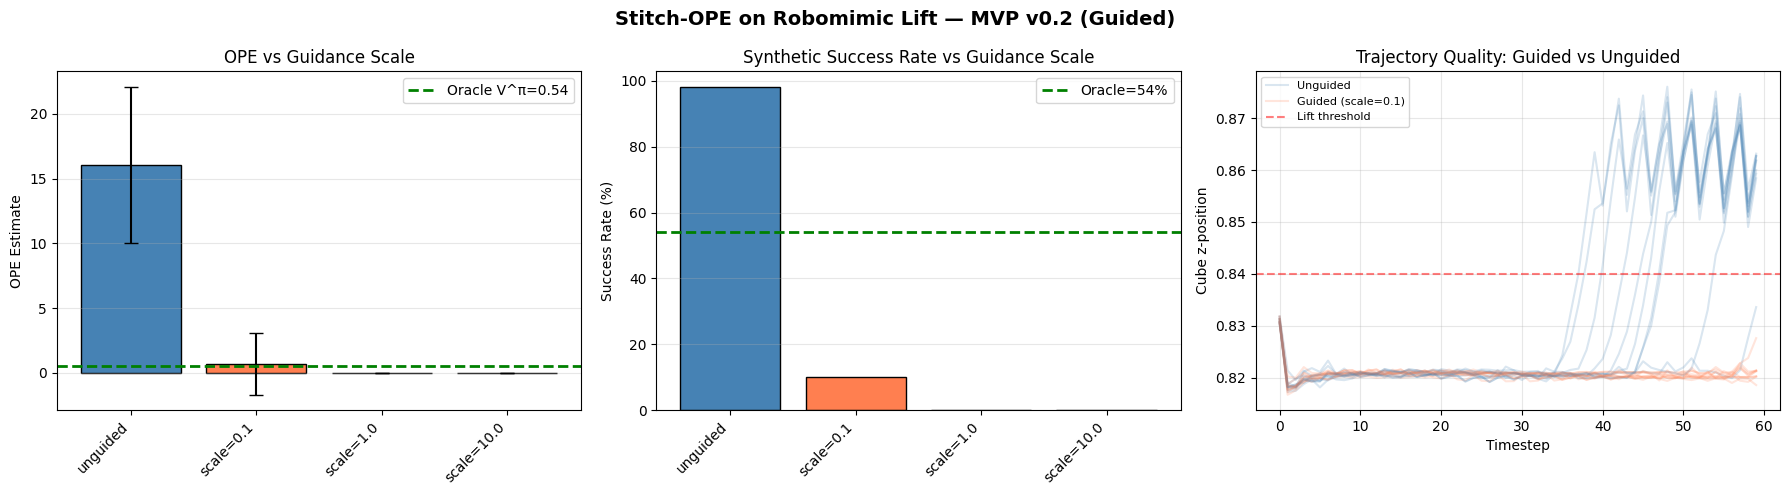

In [12]:
# ── Visualization: guidance scale comparison ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: OPE estimate by guidance scale
names = list(results_by_scale.keys())
estimates = [results_by_scale[n]["estimate"] for n in names]
stds = [results_by_scale[n]["std"] for n in names]
colors = ["steelblue"] + ["coral"] * len(GUIDANCE_SCALES)

bars = axes[0].bar(range(len(names)), estimates, color=colors, edgecolor="black")
axes[0].errorbar(range(len(names)), estimates, yerr=stds, fmt="none", color="black", capsize=5)
axes[0].axhline(y=oracle_value, color="green", linestyle="--", linewidth=2, label=f"Oracle V^π={oracle_value:.2f}")
axes[0].set_xticks(range(len(names)))
axes[0].set_xticklabels(names, rotation=45, ha="right")
axes[0].set_ylabel("OPE Estimate")
axes[0].set_title("OPE vs Guidance Scale")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# Panel 2: Success rate by guidance scale
success_rates = [results_by_scale[n]["success_rate"] * 100 for n in names]
axes[1].bar(range(len(names)), success_rates, color=colors, edgecolor="black")
axes[1].axhline(y=oracle_success_rate * 100, color="green", linestyle="--", linewidth=2, label=f"Oracle={oracle_success_rate*100:.0f}%")
axes[1].set_xticks(range(len(names)))
axes[1].set_xticklabels(names, rotation=45, ha="right")
axes[1].set_ylabel("Success Rate (%)")
axes[1].set_title("Synthetic Success Rate vs Guidance Scale")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

# Panel 3: Cube z trajectories for best guided vs unguided
best_trajs = results_by_scale[best_name]["trajs"]
for j in range(min(10, NUM_SYNTHETIC_TRAJS)):
    axes[2].plot(unguided_trajs[j, :, CUBE_Z_INDEX], alpha=0.2, color="steelblue",
                 label="Unguided" if j == 0 else "")
    axes[2].plot(best_trajs[j, :, CUBE_Z_INDEX], alpha=0.2, color="coral",
                 label=f"Guided ({best_name})" if j == 0 else "")
axes[2].axhline(y=LIFT_THRESHOLD, color="red", linestyle="--", alpha=0.5, label="Lift threshold")
axes[2].set_xlabel("Timestep")
axes[2].set_ylabel("Cube z-position")
axes[2].set_title("Trajectory Quality: Guided vs Unguided")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.suptitle("Stitch-OPE on Robomimic Lift — MVP v0.2 (Guided)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ope_summary_mvp_v02.png", dpi=150, bbox_inches="tight")
plt.show()

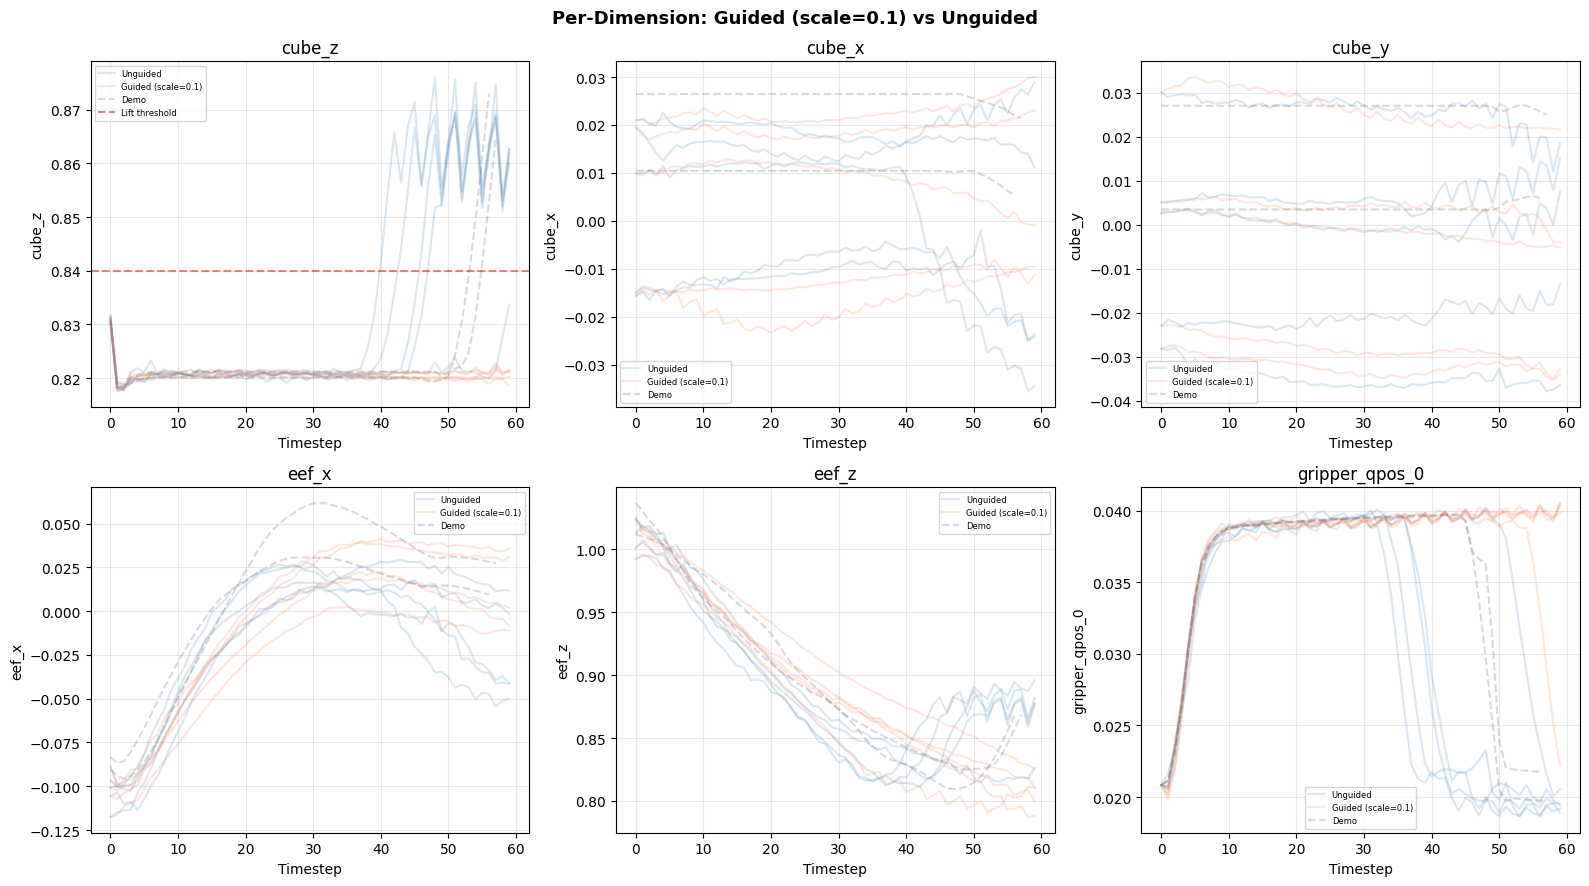

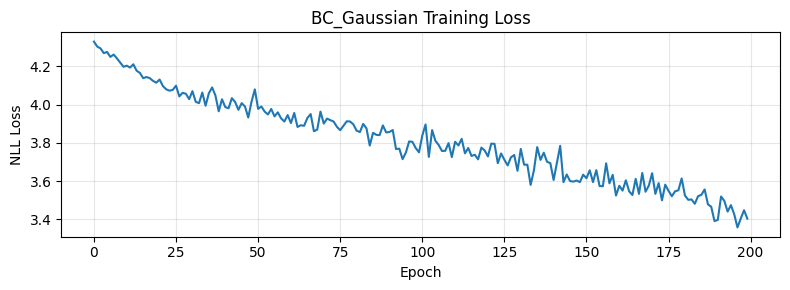

In [13]:
# ── Per-dimension trajectory comparison: best guided vs unguided ──
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

dim_names_traj = ["cube_z", "cube_x", "cube_y", "eef_x", "eef_z", "gripper_qpos_0"]
dim_indices_traj = [2, 0, 1, 6, 8, 9]

for i, (name, idx) in enumerate(zip(dim_names_traj, dim_indices_traj)):
    ax = axes[i // 3, i % 3]
    
    for j in range(min(5, NUM_SYNTHETIC_TRAJS)):
        ax.plot(unguided_trajs[j, :, idx], alpha=0.2, color="steelblue",
                label="Unguided" if j == 0 else "")
        ax.plot(best_trajs[j, :, idx], alpha=0.2, color="coral",
                label=f"Guided ({best_name})" if j == 0 else "")
    
    # Demo trajectories for reference
    for j in range(min(2, len(offline_data))):
        ax.plot(offline_data[j]["states"][:T_GEN, idx], alpha=0.3, color="gray",
                linestyle="--", label="Demo" if j == 0 else "")
    
    if name == "cube_z":
        ax.axhline(y=LIFT_THRESHOLD, color="red", linestyle="--", alpha=0.5, label="Lift threshold")
    
    ax.set_xlabel("Timestep")
    ax.set_ylabel(name)
    ax.set_title(name)
    ax.legend(fontsize=6)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Per-Dimension: Guided ({best_name}) vs Unguided", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "synthetic_trajectories_mvp_v02.png", dpi=150, bbox_inches="tight")
plt.show()

# ── BC_Gaussian training loss ──
plt.figure(figsize=(8, 3))
plt.plot(bc_losses)
plt.xlabel("Epoch")
plt.ylabel("NLL Loss")
plt.title("BC_Gaussian Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "bc_gaussian_loss.png", dpi=150)
plt.show()

## Step 6: Save Results

In [14]:
# ── Save all results to JSON ──
results = {
    "config": {
        "state_dim": STATE_DIM,
        "action_dim": ACTION_DIM,
        "transition_dim": TRANSITION_DIM,
        "chunk_size": CHUNK_SIZE,
        "n_diffusion_steps": N_DIFFUSION_STEPS,
        "dim_mults": list(DIM_MULTS),
        "base_dim": BASE_DIM,
        "predict_epsilon": PREDICT_EPSILON,
        "guidance_scales": GUIDANCE_SCALES,
        "bc_hidden_dim": BC_HIDDEN_DIM,
        "bc_train_epochs": BC_TRAIN_EPOCHS,
        "normalize_grad": NORMALIZE_GRAD,
        "num_synthetic_trajs": NUM_SYNTHETIC_TRAJS,
        "t_gen": T_GEN,
        "gamma": GAMMA,
        "diffusion_ckpt": str(DIFFUSION_CKPT_DIR),
        "target_policy_ckpt": str(CKPT_DIR),
    },
    "oracle": {
        "value": oracle_value,
        "success_rate": oracle_success_rate,
        "std": float(np.std(oracle_returns)),
    },
    "results_by_scale": {
        name: {
            "estimate": r["estimate"],
            "std": r["std"],
            "success_rate": r["success_rate"],
            "rel_error": r["rel_error"],
            "returns": r["returns"].tolist(),
        }
        for name, r in results_by_scale.items()
    },
    "best_scale": best_name,
    "best_rel_error": best_rel_error,
    "bc_gaussian": {
        "final_nll": bc_losses[-1],
        "learned_log_std": bc_policy.log_std.data.cpu().numpy().tolist(),
        "n_training_pairs": len(target_states_np),
    },
}

results_path = RESULTS_DIR / "mvp_v02_results.json"
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {results_path}")
print(f"\nFigures saved to:")
print(f"  {RESULTS_DIR / 'ope_summary_mvp_v02.png'}")
print(f"  {RESULTS_DIR / 'synthetic_trajectories_mvp_v02.png'}")
print(f"  {RESULTS_DIR / 'bc_gaussian_loss.png'}")

print("\n" + "=" * 60)
print("MVP v0.2 COMPLETE (Guided Stitching)")
print("=" * 60)
print(f"Best scale: {best_name}, OPE = {results_by_scale[best_name]['estimate']:.4f}, rel error = {best_rel_error:.2%}")
print(f"Oracle V^π = {oracle_value:.4f}")
print(f"\nNext: v0.3 — multiple target policies of varying quality → ranking metrics")

Results saved to /home1/reishuen/latent_sope/results/2026-03-10/mvp_v02_results.json

Figures saved to:
  /home1/reishuen/latent_sope/results/2026-03-10/ope_summary_mvp_v02.png
  /home1/reishuen/latent_sope/results/2026-03-10/synthetic_trajectories_mvp_v02.png
  /home1/reishuen/latent_sope/results/2026-03-10/bc_gaussian_loss.png

MVP v0.2 COMPLETE (Guided Stitching)
Best scale: scale=0.1, OPE = 0.6800, rel error = 25.93%
Oracle V^π = 0.5400

Next: v0.3 — multiple target policies of varying quality → ranking metrics
